# Download, extract, & prep mcool files

In [ ]:
%%bash

cd ~/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K

filenames=$(for each in Oligo_NN L6_CT_CTX_Glut Astro-TE_NN L2_3_IT_CTX_Glut Endo_NN L4_5_IT_CTX_Glut L5_IT_CTX_Glut L6_IT_CTX_Glut; do ls $each*; done)

mkdir originals
mv *.mcool originals/
mkdir selected && cd selected


for each in $filenames; do
	echo -e "\n======== $each"
	cooler cp ../originals/$each::/resolutions/100000 $each::/resolutions/100000 && cooler ls $each
done


for each in $(ls *.mcool); do
	echo -e "\n\n======== $each"
	cooler coarsen -k 25 $each::/resolutions/100000 -o $each::/resolutions/2500000 -a && echo && cooler ls $each
    cooler coarsen -k 5 $each::/resolutions/100000 -o $each::/resolutions/500000 -a && echo && cooler ls $each
done


for each in $(ls *.mcool); do
	echo -e "\n======== $each"
	cooler balance $each::/resolutions/2500000 --cis-only --convergence-policy 'discard' 
    cooler balance $each::/resolutions/500000 --cis-only --convergence-policy 'discard' 
done


# for each in $filenames; do
# 	echo -e "\n$each"
# 	cooler ls $each
# done


# Distance decay - mcool files

In [ ]:
%load_ext autoreload
%autoreload 2 

In [ ]:
# import core packages
import warnings
warnings.filterwarnings("ignore")
from itertools import combinations
import os

# import semi-core packages
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import numpy as np
import pandas as pd
from multiprocessing import Pool

# import open2c libraries
import bioframe

import cooler
import cooltools

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.2'):
    raise AssertionError("tutorial relies on cooltools version 0.5.2 or higher,"+
                         "please check your cooltools version and update to the latest")

# count cpus
num_cpus = os.getenv('SLURM_CPUS_PER_TASK')
if not num_cpus:
    num_cpus = os.cpu_count()
num_cpus = int(num_cpus)

In [ ]:
# resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
resolution = int(1000 * 500) # 500 kb (5e5 bp)

In [ ]:
# get centromere data from ucsc gap file
mm10_gap = pd.read_csv(
    '/net/gs/vol1/home/gesine/noble_lab/resources/genomic/gaps/ucsc.mm10.gap.txt',
    sep='\t', header=None, names=(
        'bin', 'chrom', 'start', 'end', 'ix', 'n', 'size', 'type', 'bridge'))
mm10_cens = mm10_gap.loc[mm10_gap.type == 'centromere', ['chrom', 'start', 'end']].copy().reset_index()
mm10_cens['mid'] = ((mm10_cens.start + mm10_cens.end) / 2).astype(int)
# Use bioframe to fetch the genomic features from the UCSC.
mm10_chromsizes = bioframe.fetch_chromsizes('mm10')
# create a view with chromosome arms using chromosome sizes and definition of centromeres
mm10_arms = bioframe.make_chromarms(mm10_chromsizes,  mm10_cens)
# remove chrX, chrY, chrM
mm10_arms = mm10_arms[~mm10_arms.chrom.isin(['chrX', 'chrY', 'chrM'])].reset_index(drop=True)
# remove arms that are less than the current binsize/resolution
mm10_arms = mm10_arms[(mm10_arms.end - mm10_arms.start) > resolution]

In [ ]:
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'

uri = f'{mcool_file}::/resolutions/{resolution:d}'

print(uri)
clr = cooler.Cooler(uri)

cis_cov, tot_cov = cooltools.coverage(clr, ignore_diags=1, nproc=2)
print(f"nreads: {cis_cov.sum():,}", flush=True)

In [ ]:
cvd_smooth_agg = cooltools.expected_cis(
    clr=clr,
    view_df= mm10_arms[mm10_arms.chrom.isin(clr.chromnames)].reset_index(drop=True),
    smooth=True,
    aggregate_smoothed=True,
    smooth_sigma=0.1,
    nproc=num_cpus,
    ignore_diags=1, # GC: Given very coarse bin size, only ignore main diagonal
    intra_only=True,  # GC: snm3C-seq data only contains intra-chrom counts
    #clr_weight_name=None,
)

# Compare matrices

## Load

In [7]:
import pandas as pd
import glob
import os
import ast
import numpy as np
import re
from functools import partial

from fit_pseudocount_func import load

import matplotlib.pyplot as plt
from matplotlib import colors
plt.style.use('seaborn-v0_8-paper')
%matplotlib inline
import seaborn as sns
sns.set_theme('paper', style='white')


dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'
resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
# resolution = int(1000 * 500) # 500 kb (5e5 bp)
lengths_file = '/net/gs/vol1/home/gesine/noble_lab/projects/2015_gesine_diploid/data/liu2025/unambig/astro.nreads1e9.sc_alpha-2/counts.bed'

matrix_df, sc_dis, lengths_df = load(dir_matrix2d=dir_matrix2d, mcool_file=mcool_file, lengths_file=lengths_file, resolution=resolution, verbose=True)

matrix_df['genomic_dis_ambig'] = (matrix_df['i.idx_ambig'] - matrix_df['j.idx_ambig']).abs()  # TODO remove once restarted kernel

11 genomic bins are present in MERFISH but not snm3c


### Load - manual (old)

In [19]:
import pandas as pd
import glob
import os
import ast
import numpy as np
import re
from functools import partial

import cooler

import matplotlib.pyplot as plt
from matplotlib import colors
plt.style.use('seaborn-v0_8-paper')
%matplotlib inline
import seaborn as sns
sns.set_theme('paper', style='white')

from topsy.analysis.compare_distances import make_matrix_df

In [2]:
dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'


sc_dis_intramol_file = glob.glob(os.path.join(dir_matrix2d, '*.distances.intramol.tsv.gz'))
if len(sc_dis_intramol_file) != 1:
    raise ValueError("Couldn't find unique file for intra-mol single cell distances")
sc_dis_intramol_file = sc_dis_intramol_file[0]

sc_dis = pd.read_csv(
    sc_dis_intramol_file, sep='\t', header=None, index_col=0,
    converters={0: ast.literal_eval})
sc_dis.index.name = None

In [6]:
sc_dis_diffH_file = glob.glob(os.path.join(dir_matrix2d, '*.distances.sameC-diffH.tsv.gz'))
if len(sc_dis_diffH_file) != 1:
    raise ValueError("Couldn't find unique file for intra-chrom, inter-hmlg single cell distances")
sc_dis_diffH_file = sc_dis_diffH_file[0]

sc_dis_diffH = pd.read_csv(
    sc_dis_diffH_file, sep='\t', header=None, index_col=0,
    converters={0: ast.literal_eval})
sc_dis_diffH.index.name = None

sc_dis = pd.concat([sc_dis, sc_dis_diffH])
sc_dis_diffH = None

In [7]:
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'

resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
# resolution = int(1000 * 500) # 500 kb (5e5 bp)

uri = f'{mcool_file}::/resolutions/{resolution:d}'
clr = cooler.Cooler(uri)
snm3c = np.triu(clr.matrix(balance=True if 'Raw.' in mcool_file else False)[:, :], 1)

clr_bins = clr.bins()[:].reset_index().rename({'index': 'idx_clr'}, axis=1)
clr_bins['mid'] = clr_bins[['start', 'end']].mean(axis=1).round().astype(int)
assert len(clr_bins) == snm3c.shape[0]
print(snm3c.shape)

nbins_clr = clr_bins.groupby('chrom', observed=True).size().sort_values(
    ascending=False).drop('chrX')
lengths_clr = clr_bins.groupby('chrom', observed=True).apply(
    lambda x: int(round(x.end.max() / resolution)), include_groups=False).drop('chrX')
assert (np.round((clr.chromsizes / resolution)).drop('chrX') - lengths_clr == 0).all()

(1063, 1063)


In [8]:
# because I truncated the molecules of the MERFISH data...
lengths_file = '/net/gs/vol1/home/gesine/noble_lab/projects/2015_gesine_diploid/data/liu2025/unambig/astro.nreads1e9.sc_alpha-2/counts.bed'

lengths_df = pd.read_csv(lengths_file, sep='\t')
lengths_df.columns = [c.strip('#') for c in lengths_df.columns]
for col in ['start', 'end', 'mid']:  # Round to nearest 10,000bp
    lengths_df[col] = lengths_df[col].round(-4)

n = len(lengths_df)
lengths_s = lengths_df.groupby('chrom').size().sort_values(
    ascending=False)

lengths_compare = pd.concat([lengths_s.to_frame().rename({0: 'merfish'}, axis=1), lengths_clr.to_frame().rename({0: 'snm3c'}, axis=1)], axis=1)
lengths_compare['difference'] = lengths_compare.snm3c - lengths_compare.merfish
assert (lengths_compare.difference >= 0).all()

lengths_df = lengths_df.merge(clr_bins[['chrom', 'mid', 'idx_clr']], on=['chrom', 'mid'], how='left')
print(f"{lengths_df.idx_clr.isnull().sum()} genomic bins are present in MERFISH but not snm3c")
lengths_df.index = lengths_df.idx_genome
lengths_df.index.name = None
# display(lengths_df.head())

matrix_df = make_matrix_df(lengths_df)
matrix_df = matrix_df[matrix_df['mask.sameC-sameH'] | matrix_df['mask.sameC-diffH']].drop(
    ['mask.sameC-sameH', 'mask.sameC-diffH', 'mask.diffC-sameH', 'mask.diffC-diffH', 'j.chrom'], axis=1).rename(
    {'i.chrom': 'chrom'}, axis=1)
matrix_df['i.idx_clr'] = lengths_df.loc[matrix_df['i.idx_ambig'], 'idx_clr'].values.ravel()
matrix_df['j.idx_clr'] = lengths_df.loc[matrix_df['j.idx_ambig'], 'idx_clr'].values

mask = matrix_df['i.idx_clr'].notnull() & matrix_df['j.idx_clr'].notnull()
matrix_df.loc[mask, 'snm3c'] = snm3c[matrix_df.loc[mask, 'i.idx_clr'].astype(int), matrix_df.loc[mask, 'j.idx_clr'].astype(int)]
matrix_df.loc[matrix_df['i.idx_ambig'] == matrix_df['j.idx_ambig'], 'snm3c'] = np.nan

matrix_df = matrix_df.loc[matrix_df.index.isin(sc_dis.index)]

11 genomic bins are present in MERFISH but not snm3c


## Compare

In [ ]:
results_df = None
results = []
if os.path.exists('pseudocounts_vs_snm3c.tsv'):
    results_df = pd.read_csv('pseudocounts_vs_snm3c.tsv', sep='\t')
    results = results_df.to_dict(orient='records')
print(f"{len(results_df)} entries:")
display(results_df.head())

### With/without inter-hmlg data

#### Comparisons

In [732]:
result_idx = 0

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.7951     current=0.7954     adding inter-hmlg ↑R by 0.03009%
med ... prev=0.6686     current=0.6665     adding inter-hmlg ↑R by -0.3209%


In [739]:
result_idx = 50

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.7921     current=0.793     adding inter-hmlg ↑R by 0.1111%
med ... prev=0.8351     current=0.8321     adding inter-hmlg ↑R by -0.3673%


In [758]:
result_idx = results_df.loc[results_df.func == 'power'].index[0]

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.7479     current=0.752     adding inter-hmlg ↑R by 0.5507%
med ... prev=0.7597     current=0.7625     adding inter-hmlg ↑R by 0.3647%


In [759]:
result_idx = results_df.loc[results_df.func == 'thresholded'].index[0]

tmp = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df.loc[result_idx].to_frame().T.reset_index(drop=True), plot=False)[0]
for x in ('mean', 'med'):
    prev = results_df.loc[result_idx, x]
    print(f"{x:<4}... prev={prev:<4.4g}     current={tmp[x]:<4.4g}     adding inter-hmlg ↑R by {(tmp[x] - prev)/prev * 100:.4g}%")

mean... prev=0.739     current=0.7376     adding inter-hmlg ↑R by -0.1875%
med ... prev=nan      current=nan      adding inter-hmlg ↑R by nan%


#### Re-generate with inter-hmlg data

In [794]:
func = 'logistic'

filtered_for_func = results_df_intraM[(results_df_intraM.func == func)]
# display(filtered_for_func.loc[filtered_for_func.index.values[40:]])

# filtered_for_func.index.values[:40]

i = 40
# results_df_intraM.loc[i, 'func_kwargs']

In [789]:
# results_df_intraM = results_df.copy()

func = 'logistic'

filtered_for_func = results_df_intraM[(results_df_intraM.func == func)]
display(filtered_for_func)

for i in filtered_for_func.index.values[40:]:
    
    print(f'{i}')
    results.append(plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df_intraM.loc[i].to_frame().T.reset_index(drop=True), plot=False)[0])
    results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
    results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)
    # display(results_df.head(1))

print('\nFINAL:')
display(results_df.head())

,func,func_kwargs,mean,med
0,logistic,"k=-25, v=2, x0=0.4",0.795123,0.668640
1,logistic,"k=-35, v=3, x0=0.4",0.795006,0.697630
2,logistic,"k=-45, v=4, x0=0.4",0.794885,0.711934
3,logistic,"k=-50, v=4, x0=0.4",0.794845,0.668559
4,logistic,"k=-40, v=3, x0=0.4",0.794814,0.639160
...,...,...,...,...
153,logistic,"k=-25, v=2, x0=1",0.730676,0.831061
155,logistic,"k=-2, v=1, x0=0",0.727009,0.755504
159,logistic,"k=-2.5, v=2, x0=0",0.698433,0.704401
160,logistic,"k=-15, v=1, x0=0",0.688459,0.580504


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39

FINAL:


,func,func_kwargs,mean,med
0,logistic,"k=-25, v=2, x0=0.4",0.795362,0.666494
1,logistic,"k=-35, v=3, x0=0.4",0.795301,0.695312
2,logistic,"k=-20, v=2, x0=0.4",0.795257,0.750934
3,logistic,"k=-45, v=4, x0=0.4",0.795207,0.709532
4,logistic,"k=-30, v=3, x0=0.4",0.795144,0.750747


### Logistic

#### Examining specific genomic distance bins

In [58]:
# print(bins_per_genomic_dis[bins_per_genomic_dis >= 2000].index.max())
# results_df

display(results_df[(results_df.func == res['func']) & (results_df.func_kwargs == res['func_kwargs']) & (
    results_df.genomic_dis_min == results_df.genomic_dis_max)])

,func,func_kwargs,mean,med,genomic_dis_min,genomic_dis_max
2,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.679309,0.476740,9,9
3,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.673861,0.399563,10,10
4,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.662213,0.395808,19,19
5,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.643346,0.240054,17,17
6,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.627839,0.322685,13,13
7,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.626449,0.340662,8,8
8,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.621305,0.362002,14,14
9,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.618755,0.275938,18,18
10,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.612833,0.318421,11,11
11,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.607437,0.330217,5,5



GENOMIC DIS BIN = 5


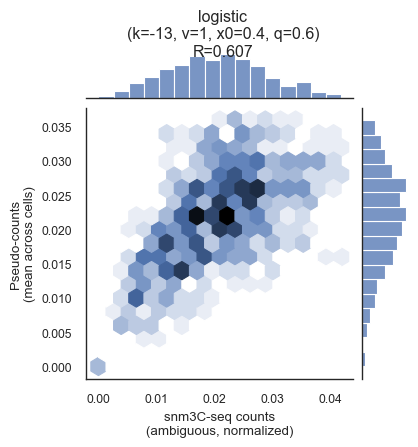


GENOMIC DIS BIN = 6


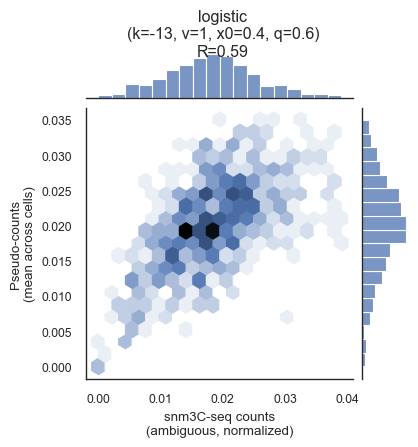


GENOMIC DIS BIN = 7


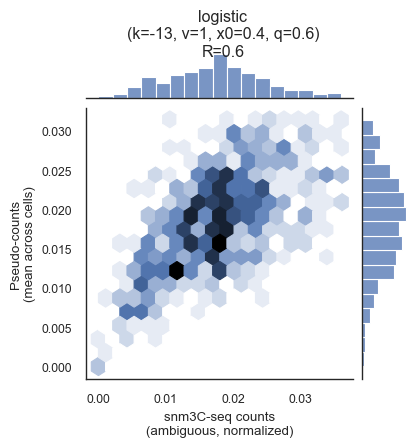


GENOMIC DIS BIN = 8


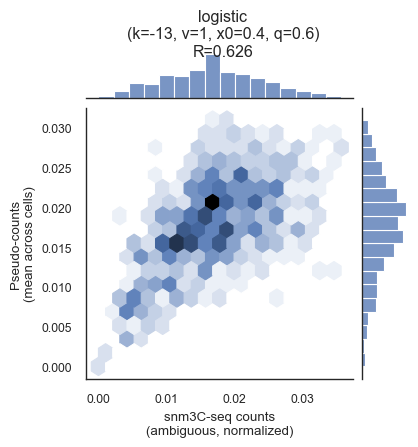


GENOMIC DIS BIN = 9


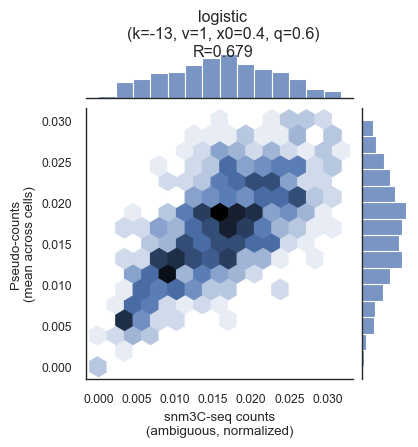


GENOMIC DIS BIN = 10


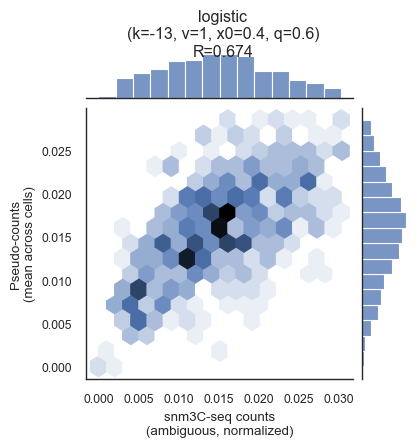


GENOMIC DIS BIN = 11


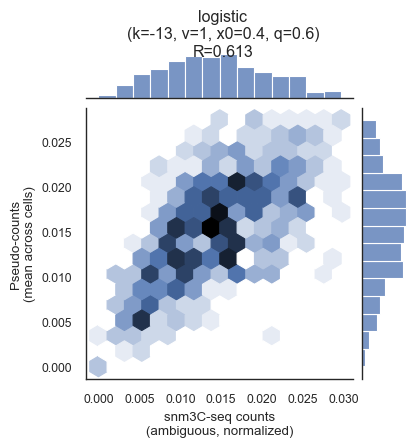


GENOMIC DIS BIN = 12


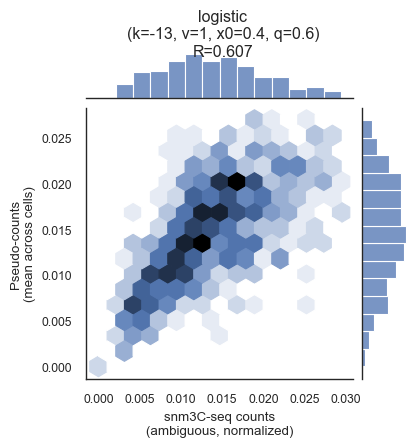


GENOMIC DIS BIN = 13


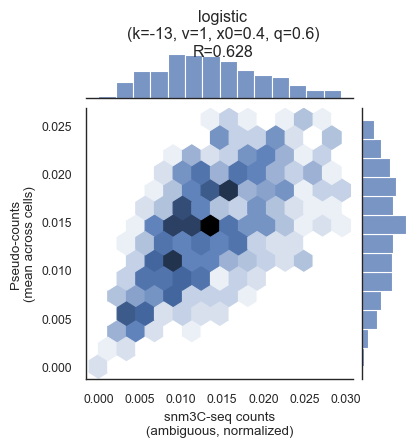


GENOMIC DIS BIN = 14


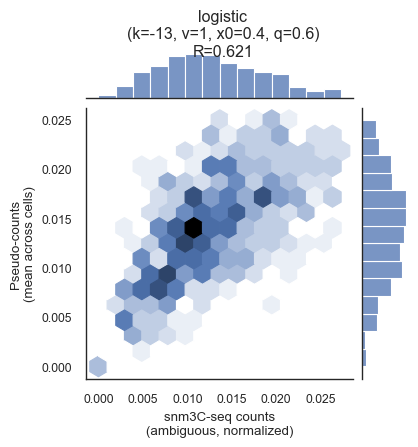


GENOMIC DIS BIN = 15


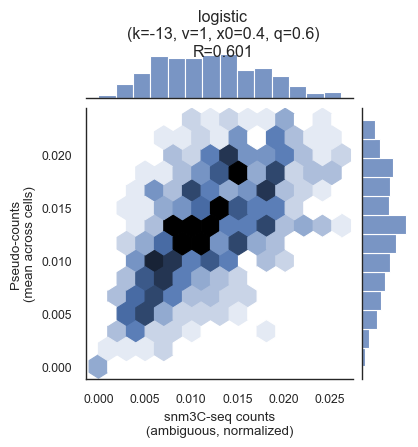


GENOMIC DIS BIN = 16


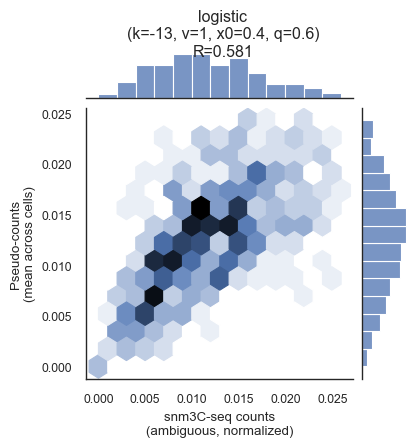


GENOMIC DIS BIN = 17


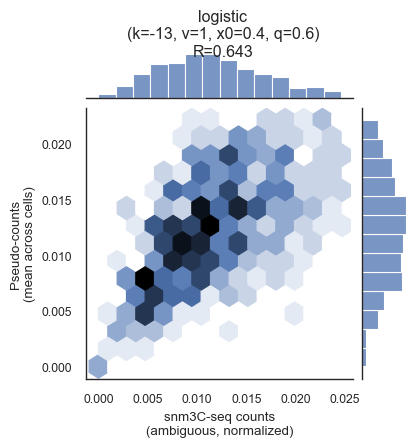


GENOMIC DIS BIN = 18


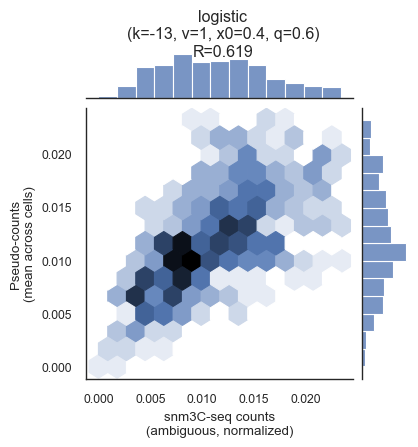


GENOMIC DIS BIN = 19


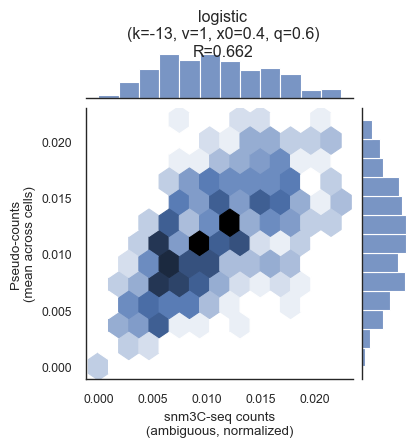

,func,func_kwargs,mean,med,genomic_dis_min,genomic_dis_max
2,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.679309,0.476740,9,9
3,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.673861,0.399563,10,10
4,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.662213,0.395808,19,19
5,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.643346,0.240054,17,17
6,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.627839,0.322685,13,13


In [54]:
# k, x0 = np.array([-14.71402465, 0.45154928]); v = q = 1
k=-13; v=1; x0=0.4; q=0.6

plot = False

# ====== PER GENOMIC DIS
bins_per_genomic_dis = matrix_df.genomic_dis_ambig.value_counts()
snm3c_per_genomic_dis = matrix_df[matrix_df.genomic_dis.notnull()].groupby('genomic_dis').snm3c.mean()

# ====== SINGLE GENOMIC DISTANCE BINS
# genomic_dis_list = [1, 2, 3, 4]
genomic_dis_list = np.arange(5, bins_per_genomic_dis[bins_per_genomic_dis >= 2000].index.max())
for genomic_dis in genomic_dis_list:
    if plot:
        print(f"\nGENOMIC DIS BIN = {genomic_dis}")
    res = assess_pseudocounts(matrix_df[matrix_df.genomic_dis_ambig == genomic_dis], sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, v=v, x0=x0, q=q), plot=plot)[0]
    if not plot:
        print(f"\nGENOMIC DIS BIN = {genomic_dis:<4}   R={res['mean']:.3g}")
    res['genomic_dis_min'] = res['genomic_dis_max'] = genomic_dis
    results.append(res)
    results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
    results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)
display(results_df[(results_df.func == res['func']) & (results_df.func_kwargs == res['func_kwargs']) & (
    results_df.genomic_dis_min == results_df.genomic_dis_max)].head())


# # ====== RANGES OF GENOMIC DISTANCE
# genomic_dis_ranges = [(1, 3), (10, np.inf)]
# for genomic_dis_min, genomic_dis_max in genomic_dis_ranges:
#     if plot:
#         print(f"\nGENOMIC DIS: {genomic_dis_min} <= s <= {genomic_dis_max}")
#     res = assess_pseudocounts(matrix_df[matrix_df.genomic_dis_ambig <= genomic_dis_max], sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, v=v, x0=x0, q=q), plot=plot)[0]
#     if not plot:
#         print(f"\nGENOMIC DIS: {genomic_dis_min} <= s <= {genomic_dis_max}\t\tR={res['mean']:.3g}")
#     res['genomic_dis_min'] = genomic_dis_min
#     res['genomic_dis_max'] = genomic_dis_max
#     results.append(res)
#     results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
#     results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)
# display(results_df[(results_df.func == res['func']) & (results_df.func_kwargs == res['func_kwargs']) & (
#     results_df.genomic_dis_min != results_df.genomic_dis_max)].head())

# # ====== TRANSFER FUNC
# plot_transfer_func(sc_dis=sc_dis, func=logistic, func_kwargs=dict(k=k, v=v, x0=x0, q=q))

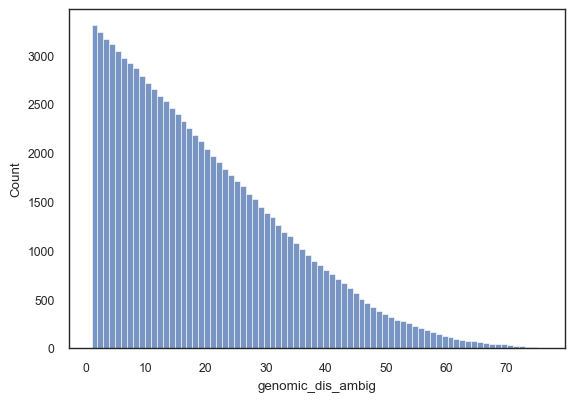

genomic_dis_ambig
1     3308
2     3244
3     3164
4     3112
5     3048
      ... 
72      20
73      16
74      12
75       8
76       4
Name: count, Length: 77, dtype: int64

In [49]:
sns.histplot(
    matrix_df[matrix_df.genomic_dis_ambig.notnull() & (matrix_df.genomic_dis_ambig != 0)],
    x='genomic_dis_ambig', bins=matrix_df.genomic_dis_ambig.max())
plt.show()

bins_per_genomic_dis = matrix_df.genomic_dis_ambig.value_counts()
bins_per_genomic_dis

#### Comparing to best params from inference

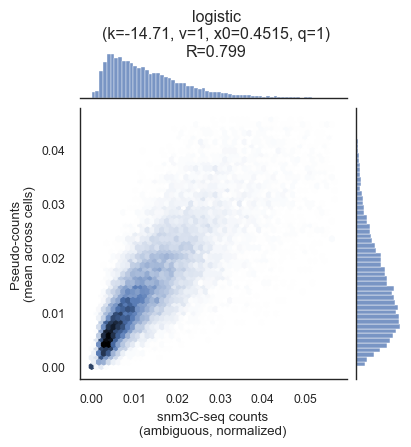

{'func': 'logistic',
 'func_kwargs': 'k=-14.71, v=1, x0=0.4515, q=1',
 'mean': 0.7992903611462948,
 'med': 0.5962624193065686}

In [37]:
k, x0 = np.array([-14.71402465, 0.45154928])
v = q = 1

assess_pseudocounts(matrix_df, sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, v=v, x0=x0, q=q), plot=True)[0]

plot_transfer_func(sc_dis=sc_dis, func=logistic, func_kwargs=dict(k=k, v=v, x0=x0, q=q))

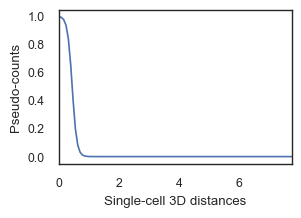

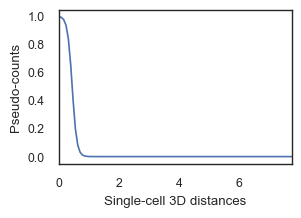

In [46]:
plot_transfer_func(sc_dis=sc_dis, func=logistic, func_kwargs=dict(k=k, v=v, x0=x0, q=q))
plot_best_transfer_func(results_df, sc_dis)

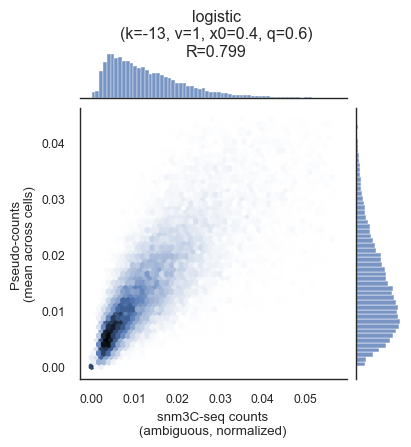

{'func': 'logistic',
 'func_kwargs': 'k=-13, v=1, x0=0.4, q=0.6',
 'mean': 0.7992016084888707,
 'med': 0.6570021242547587}

In [41]:
plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df)[0]

#### Manual

In [ ]:
display(results_df.head(1).rename({0: f"BEST"}))
print()

for v in [1]:
    for k in [round(-13 * v, 2)]:
        for x0 in [0.4]:
            for q in [0.6]:
                results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=logistic, transfer_func_kwargs=dict(k=k, v=v, x0=x0, q=q))[0])
    results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
    results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)
    display(results_df[results_df.func_kwargs.str.contains(f'{k=},')].head(1))

results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)
print('\nFINAL:')
display(results_df.head())


print('\n...')
display(results_df[results_df.func_kwargs.str.contains('q=') | (results_df.func_kwargs == 'k=-25, v=2, x0=0.4')].head())


plot_best_transfer_func(results_df, sc_dis)
_ = plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df)

,func,func_kwargs,mean,med
BEST,logistic,"k=-13, v=1, x0=0.4, q=0.6",0.795715,0.655148


### Threshold power func

In [539]:
# TODO Test this... with upper/lower cutoff, like for dist decay below !!!!

### Thresholded func

,func,func_kwargs,mean,med
THRESH: BEST,thresholded,cutoff=0.5,0.739005,NaN


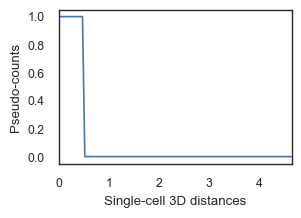

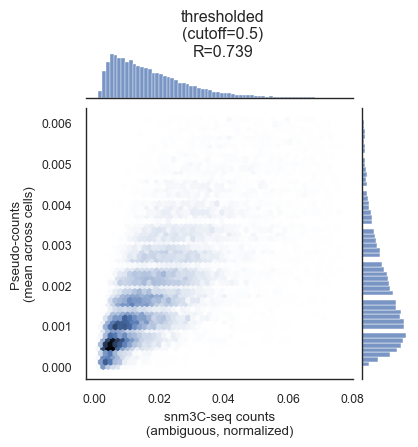

In [538]:
# results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=thresholded, transfer_func_kwargs=dict(cutoff=0.5), plot=False)[0])
# results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
# results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)

results_df_thr = results_df[results_df.func == 'thresholded'].reset_index(drop=True)
display(results_df_thr.head(1).rename({0: f"THRESH: BEST"}))
plot_best_transfer_func(results_df_thr, sc_dis=sc_dis)
plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df_thr)

### Power func

,func,func_kwargs,mean,med
POWER: BEST,power,alpha=-1.35,0.747918,0.759707


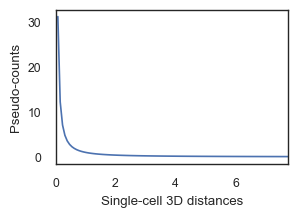

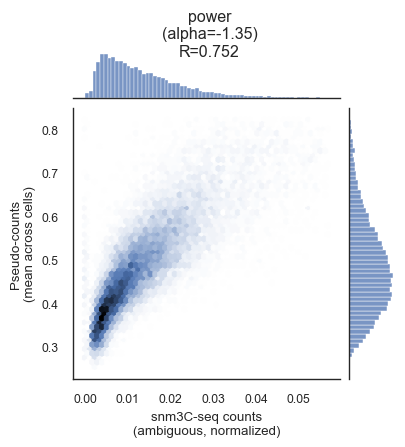

({'func': 'power',
  'func_kwargs': 'alpha=-1.35',
  'mean': 0.7520365004134979,
  'med': 0.7624774461472053},
 (              i.idx  j.idx  i.idx_chrom  j.idx_chrom  chrom  i.idx_ambig  \
  (0, 1)            0      1            0            1   chr1            0   
  (0, 2)            0      2            0            2   chr1            0   
  (0, 3)            0      3            0            3   chr1            0   
  (0, 4)            0      4            0            4   chr1            0   
  (0, 5)            0      5            0            5   chr1            0   
  ...             ...    ...          ...          ...    ...          ...   
  (1922, 1924)   1922   1924           20           22  chr19          959   
  (1922, 1925)   1922   1925           20           23  chr19          959   
  (1923, 1924)   1923   1924           21           22  chr19          960   
  (1923, 1925)   1923   1925           21           23  chr19          960   
  (1924, 1925)   1924   1925   

In [747]:
# results.append(assess_pseudocounts(matrix_df, sc_dis, transfer_func=power, transfer_func_kwargs=dict(alpha=-1.3), plot=False)[0])
# results_df = pd.DataFrame(results).drop_duplicates().sort_values('mean', ascending=False).reset_index(drop=True)
# results_df.to_csv('pseudocounts_vs_snm3c.tsv', sep='\t', index=False)

# results_df.loc[results_df.func_kwargs.str.contains('alpha'), 'func'] = 'power'

results_df_power = results_df[results_df.func == 'power'].reset_index(drop=True)
display(results_df_power.head(1).rename({0: f"POWER: BEST"}))
plot_best_transfer_func(results_df_power, sc_dis=sc_dis)
plot_best_result(matrix_df, sc_dis=sc_dis, results_df=results_df_power)

## Fxn - compare

In [15]:
def logistic2(x, alpha, x0=0, v=1, q=1, L=1):
    assert alpha < 0
    tmp = -alpha * v * (x - x0)
    res = L / np.power(1 + q * np.exp(tmp), 1 / v)
    # res = np.exp(np.log(L) - np.log1p(q * np.exp(tmp))) / v
    return res

def logistic(x, k, x0=0, v=1, q=1, L=1):
    assert k < 0
    tmp = -k * (x - x0)
    res = L / np.power(1 + q * np.exp(tmp), 1 / v)
    # res = np.exp(np.log(L) - np.log1p(q * np.exp(tmp))) / v
    return res

def power(x, alpha):
    if isinstance(x, np.ndarray):
        y = np.full_like(x, np.nan)
        mask = (~np.isnan(x)) & (x > 0)
        y[mask] = np.power(x[mask], alpha)
        return y
    else:
        return x.pow(alpha)

def thresholded(x, cutoff):
    return x <= cutoff

In [16]:
def assess_pseudocounts(matrix_df, sc_dis, transfer_func, transfer_func_kwargs=None,
                        plot=False, perc_cutoff=0.95, agg_func='mean', verbose=False):
    if transfer_func_kwargs is None:
        transfer_func_kwargs = {}
    counts_sc = transfer_func(sc_dis, **transfer_func_kwargs)
    counts = pd.concat([
        counts_sc.mean(axis=1).to_frame().rename({0: 'pc_mean'}, axis=1),
        counts_sc.median(axis=1).to_frame().rename({0: 'pc_med'}, axis=1)], axis=1)
    matrix_df = matrix_df[matrix_df.snm3c.notnull()].join(counts, how='inner')

    # Ambiguate matrix_df
    grp_cols = ['i.idx_ambig', 'j.idx_ambig', 'chrom', 'i.idx_chrom', 'j.idx_chrom',
                'i.idx_clr', 'j.idx_clr']
    excluded_cols = ['i.idx', 'j.idx', 'i.hmlg', 'j.hmlg', 'mask.diffM', 'mask.nghbr', 'genomic_dis']
    matrix_df_ambig = matrix_df.copy()
    mask_swap = matrix_df['i.idx_ambig'] > matrix_df['j.idx_ambig']
    if mask_swap.any():  # Ambig index pair should fall in upper triangular
        for col in ('idx_ambig', 'idx_chrom', 'idx_clr'):
            matrix_df_ambig.loc[mask_swap, f'i.{col}'] = matrix_df.loc[mask_swap, f'j.{col}']
            matrix_df_ambig.loc[mask_swap, f'j.{col}'] = matrix_df.loc[mask_swap, f'i.{col}']
    matrix_df_ambig = matrix_df_ambig[  # Remove diagonal of ambig
        matrix_df_ambig['i.idx_ambig'] != matrix_df_ambig['j.idx_ambig']].drop(
            excluded_cols, axis=1)
    matrix_df_ambig = matrix_df_ambig.groupby(grp_cols).sum() / 4
    matrix_df_ambig.reset_index(level=np.arange(len(grp_cols)).tolist(), inplace=True)

    pearson_r = {
        'func': transfer_func.__name__,
        'func_kwargs': ', '.join([f"{k}={v:.4g}" for k, v in transfer_func_kwargs.items()]),
        'mean': float(matrix_df_ambig[["snm3c", "pc_mean"]].corr(method='pearson').values[0, 1]),
        'med': float(matrix_df_ambig[["snm3c", "pc_med"]].corr(method='pearson').values[0, 1])}
    if verbose:
        print(f"Pearson R:  mean={pearson_r['mean']:.3g}\n             med={pearson_r['med']:.3g}", flush=True)

    # print(f"From pd: {pearson_r['mean']:.3g}")
    # x = matrix_df_ambig.snm3c.values
    # y = matrix_df_ambig.pc_mean.values
    # m = (~np.isnan(x)) & (~np.isnan(y))
    # tmp = np.corrcoef(x[m], y[m])
    # print(tmp)
    # print(f"From np: {tmp[0, 1]:.3g}")

    if plot:
        plot_counts_corr(matrix_df_ambig, pearson_r=pearson_r, perc_cutoff=perc_cutoff, agg_func=agg_func)

    return pearson_r, (matrix_df, matrix_df_ambig)


def plot_counts_corr(matrix_df_ambig, perc_cutoff=0.95, agg_func='mean', pearson_r=None, title=None):
    xmax = matrix_df_ambig.snm3c.quantile(perc_cutoff)
    ymax = matrix_df_ambig[f"pc_{agg_func}"].quantile(perc_cutoff)
    
    g = sns.jointplot(
        data=matrix_df_ambig[(matrix_df_ambig.snm3c <= xmax) & (matrix_df_ambig[f"pc_{agg_func}"] <= ymax)],
        x="snm3c", y=f"pc_{agg_func}", kind='hex', height=4)
    plt.ylabel(f"Pseudo-counts\n({agg_func} across cells)")
    plt.xlabel(f"snm3C-seq counts\n(ambiguous, normalized)")
    if pearson_r is not None:
        if title is None:
            title = f"{pearson_r['func']}\n({pearson_r['func_kwargs']})"
        title = f"{title}\nR={pearson_r[agg_func]:.3g}"
    if title is not None:
        g.fig.suptitle(title, y=1.07)
    plt.show()

In [21]:
def get_best_func(results_df):
    func_dict = {'logistic': logistic, 'power': power, 'thresholded': thresholded}
    func = func_dict[results_df.loc[0, 'func']]
    func_kwargs = ast.literal_eval("{'" + results_df.loc[0, 'func_kwargs'].replace(
        '=', "': ").replace(', ', ", '") + "}")
    return func, func_kwargs


def plot_best_result(matrix_df, sc_dis, results_df, plot=True):
    func, func_kwargs = get_best_func(results_df)
    pearson_r, (matrix_df, matrix_df_ambig) = assess_pseudocounts(matrix_df, sc_dis, transfer_func=func, transfer_func_kwargs=func_kwargs, plot=plot)
    return pearson_r, (matrix_df, matrix_df_ambig)


def plot_transfer_func(sc_dis, func, func_kwargs=None, title=None):
    xmax = np.quantile(sc_dis.values[~np.isnan(sc_dis.values)], 0.99)
    x = np.linspace(0, xmax, num=100)
    if func_kwargs is None:
        y = func(x)
    else:
        y = func(x, **func_kwargs)
    
    fig = plt.figure()
    plt.plot(x, y)
    plt.xlim(0, xmax)
    fig.set_size_inches((3, 2))
    if title is None:
        title = func.__name__ + '\n(' + ', '.join(
            [f"{k}={v:.4g}" for k, v in func_kwargs.items()]) + ')'
    plt.title(title)
    # plt.title(results_df.loc[0, 'func'] + '\n' + results_df.loc[0, 'func_kwargs'])
    plt.xlabel('Single-cell 3D distances')
    plt.ylabel('Pseudo-counts')
    plt.show()


def plot_best_transfer_func(results_df, sc_dis):
    func, func_kwargs = get_best_func(results_df)
    plot_transfer_func(sc_dis=sc_dis, func=func, func_kwargs=func_kwargs)

## Looking at inter-hmlg data (intra-chrom only)

### Plot inter-hmlg data

INTER-HMLG DATA - SINGLE-CELL:

NaNs are 96.8% of the data

5,360,238 non-NaN values, summary:
mean     4.18
std      1.71
min      0.03
25%      2.94
50%      4.06
75%      5.29
max     13.14


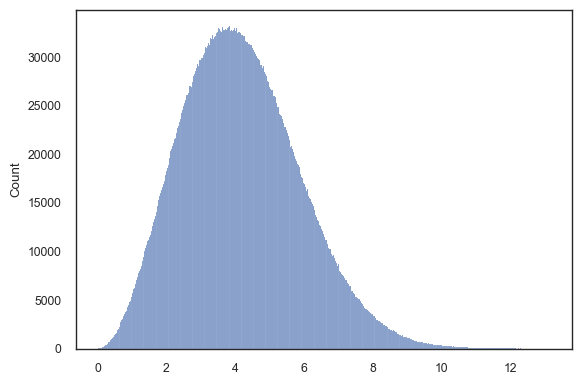



INTER-HMLG DATA - MEAN ACROSS CELLS:

NaNs are 0% of the data

45,598 non-NaN values, summary:
mean    4.17
std     0.36
min     2.61
25%     3.97
50%     4.21
75%     4.43
max     5.42


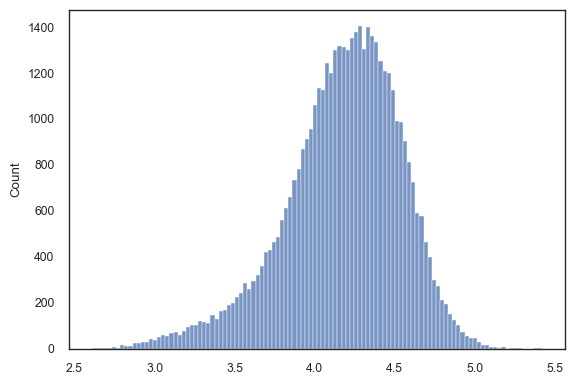

In [710]:
tmp = sc_dis.loc[matrix_df[matrix_df['mask.diffM']].index].values
print(f"INTER-HMLG DATA - SINGLE-CELL:\n\nNaNs are {np.isnan(tmp).sum() / tmp.size * 100:.3g}% of the data")
tmp = tmp[~np.isnan(tmp)]
print(f'\n{tmp.size:,} non-NaN values, summary:\n' + pd.Series(tmp).describe().round(2).drop('count').to_string())
sns.histplot(tmp)
plt.show()

tmp = sc_dis.loc[matrix_df[matrix_df['mask.diffM']].index].mean(axis=1).values
print(f"\n\nINTER-HMLG DATA - MEAN ACROSS CELLS:\n\nNaNs are {np.isnan(tmp).sum() / tmp.size * 100:.3g}% of the data")
tmp = tmp[~np.isnan(tmp)]
print(f'\n{tmp.size:,} non-NaN values, summary:\n' + pd.Series(tmp).describe().round(2).drop('count').to_string())
sns.histplot(tmp)
plt.show()

tmp = None

### Test: aggregate `matrix_df` to ambiguous, when using inter-hmlg data

In [670]:
# grp_cols = ['i.idx_ambig', 'j.idx_ambig', 'chrom', 'i.idx_chrom', 'j.idx_chrom',
#             'genomic_dis', 'mask.nghbr', 'i.idx_clr', 'j.idx_clr']
# excluded_cols = ['i.idx', 'j.idx', 'i.hmlg', 'j.hmlg', 'mask.diffM']


# # old version
# tmp = matrix_df[matrix_df.columns[~matrix_df.columns.isin(
#     excluded_cols)]].groupby(grp_cols).apply(lambda x: len(x), include_groups=False)
# print(tmp.value_counts())
# tmp = None

1    22744
3    21855
Name: count, dtype: int64


In [675]:
grp_cols = ['i.idx_ambig', 'j.idx_ambig', 'chrom', 'i.idx_chrom', 'j.idx_chrom',
            'i.idx_clr', 'j.idx_clr']
excluded_cols = ['i.idx', 'j.idx', 'i.hmlg', 'j.hmlg', 'mask.diffM', 'mask.nghbr', 'genomic_dis']
matrix_df_ambig = matrix_df.copy()
mask_swap = matrix_df['i.idx_ambig'] > matrix_df['j.idx_ambig']
if mask_swap.any():  # Ambig index pair should fall in upper triangular
    for col in ('idx_ambig', 'idx_chrom', 'idx_clr'):
        matrix_df_ambig.loc[mask_swap, f'i.{col}'] = matrix_df.loc[mask_swap, f'j.{col}']
        matrix_df_ambig.loc[mask_swap, f'j.{col}'] = matrix_df.loc[mask_swap, f'i.{col}']
matrix_df_ambig = matrix_df_ambig[  # Remove diagonal
    matrix_df_ambig['i.idx_ambig'] != matrix_df_ambig['j.idx_ambig']].drop(excluded_cols, axis=1)
print(len(matrix_df_ambig), len(matrix_df))

tmp = matrix_df_ambig.groupby(grp_cols).apply(lambda x: len(x), include_groups=False)
print(tmp.value_counts())

tmp = tmp.to_frame().reset_index(level=np.arange(len(grp_cols)).tolist()).rename({0: 'n'}, axis=1)
print((tmp['i.idx_ambig'] > tmp['j.idx_ambig']).any())

tmp = None
matrix_df_ambig = None

89396 90296
4    21855
Name: count, dtype: int64
False


# Infer pseudocounts transfer func params

## Load

In [25]:
%run fit_pseudocount_func.py

In [1]:
import pandas as pd
import glob
import os
import ast
import numpy as np
import re

from fit_pseudocount_func import prep_data_for_inference
# from fit_pseudocount_func import load, prep_data_for_inference, ambiguate_matrix_df_for_inference, InferArgs, _setup_jax

dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'
# mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Q.100K/selected/Astro-TE_NN.Q.100K.mcool'
mcool_file = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/data/snm3C-seq/pseudobulk_3C/nobackup/Raw.100K/selected/Astro-TE_NN.Raw.100K.mcool'
resolution = int(1000 * 1000 * 2.5) # 2.5 Mb (2.5e6 bp)
# resolution = int(1000 * 500) # 500 kb (5e5 bp)

data_outdir=''
name=''



# # lengths_file = '/net/gs/vol1/home/gesine/noble_lab/projects/2015_gesine_diploid/data/liu2025/unambig/astro.nreads1e9.sc_alpha-2/counts.bed'  # XXX remove after kernel restart
# lengths_file = os.path.join(os.path.dirname(dir_matrix2d), 'counts.bed')  # XXX remove after kernel restart
# # Load
# matrix_df, sc_dis, lengths_df = load(dir_matrix2d=dir_matrix2d, mcool_file=mcool_file, lengths_file=lengths_file, resolution=resolution, verbose=True)
# # Setup data for inference
# _, snm3c, dis_idx = ambiguate_matrix_df_for_inference(matrix_df)
# sc_dis_arr = sc_dis.loc[dis_idx].values
# sc_dis_arr[np.isnan(sc_dis_arr)] = 0
# sc_dis_arr = np.asarray(sc_dis_arr, order='C')
# data = InferArgs(snm3c=snm3c, sc_dis_arr=sc_dis_arr)
# snm3c = sc_dis_arr = matrix_df = sc_dis = None  # Save memory while in jupyterlab


data = prep_data_for_inference(dir_matrix2d, mcool_file=mcool_file, resolution=resolution, verbose=True, data_outdir=data_outdir, name=name)

11 genomic bins are present in MERFISH but not snm3c


In [ ]:
data_outdir = 'nobackup'
name = ''

name = '' if name is None else f"{name}."
npzfile = os.path.join(data_outdir, f'{name}pseudocounts_infer_logistic.data.npz')

os.makedirs(data_outdir, exist_ok=True)
np.savez(npzfile, snm3c=snm3c, sc_dis_arr=sc_dis_arr)

## Infer

### Infer with 'Pearson'

In [15]:
_setup_jax(traceback=False, debug_nan_inf=False)


# init = None; seed = 0; intramol_only = False; infer_nu=True; infer_q=True
# # k=-17.91  d₀=0.4822  𝜈=0.5953  q=0.8201  ... R=0.79947835 ** using k = alpha * nu !!
# init = np.array([-17.91001729, 0.48224009, 0.59530008, 0.82009542])  # R=0.799478346764533

# init = None; seed = 1; intramol_only = False; infer_nu=True; infer_q=True
# # k=-24.83  d₀=0.002421  𝜈=4.582   q=47.43   ... R=0.79241673 ** using k = alpha !!

# init = None; seed = 1; intramol_only = True; infer_nu=True; infer_q=True
# # k=-24.41  d₀=0.9505  𝜈=7.208   q=47.43   ... R=0.72496335
# # k=-24.51  d₀=0       𝜈=6.818   q=47.43   ... R=0.77727566
# # k=-24.74  d₀=0       𝜈=6.024   q=47.43   ... R=0.7826702

# init = None; seed = 1; intramol_only = True; infer_nu=True; infer_q=False
# # k=-24.41  d₀=0.9505  𝜈=7.208   q=1       ... R=0.70416431
# # k=-24.96  d₀=0.03108  𝜈=4.424   q=1       ... R=0.78849082
# # k=-25.32  d₀=1       𝜈=2.22e-14  q=1       ... R=-1  
# init = None; seed = 1; intramol_only = False; infer_nu=True; infer_q=False
# # # k=-24.41  d₀=0.9505  𝜈=7.208   q=1       ... R=0.0.71330448


# init = None; seed = 1; intramol_only = False; infer_nu=False; infer_q=False
# # k=-24.41  d₀=0.9505  𝜈=1       q=1       ... R=0.75246586
# # k=-14.71  d₀=0.4515  𝜈=1       q=1       ... R=0.79936276
# # init = array([-14.71402465,   0.45154928])

# init = None; seed = 0; intramol_only = False; infer_nu=False; infer_q=False
# # k=-18.15  d₀=0.2698  𝜈=1       q=1       ... R=0.77376346
# # k=-14.71  d₀=0.4515  𝜈=1       q=1       ... R=0.79936276
# # array([-14.71465111,   0.4515491 ])} # **** using this

# init = None; seed = 0; intramol_only = False; infer_nu=False; infer_q=False
# # k=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... R=0.7352575
# # k=-18.17  d₀=0.4805  𝜈=0.9109  q=1       ... R=0.79918057
# # array([-18.16812632,   0.48048507,   0.91086788])


d = estimate_logistic_param(
    data=data, intramol_only=intramol_only, infer_nu=infer_nu, infer_q=infer_q, init=init, bounds=None, seed=seed,
    max_iter=1e20, jitted=True, verbose=2)
d

α=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... INIT
OPTIMIZING:
α=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... R=0.7352575
α=-18.22  d₀=0.2698  𝜈=0.5205  q=1       ... R=0.7352575
α=-18.21  d₀=0.9301  𝜈=0.6513  q=1       ... R=0.76010447
α=-18.21  d₀=0.8153  𝜈=0.636   q=1       ... R=0.7756828
α=-18.21  d₀=0       𝜈=0.5     q=1       ... R=0.3813647
α=-18.21  d₀=0.724   𝜈=0.6208  q=1       ... R=0.78637919
α=-18.21  d₀=0.2851  𝜈=0.5404  q=1       ... R=0.74699552
α=-18.21  d₀=0.5595  𝜈=0.5907  q=1       ... R=0.79842481
α=-18.21  d₀=0.4972  𝜈=0.5804  q=1       ... R=0.79855253
α=-18.21  d₀=0.5283  𝜈=0.5855  q=1       ... R=0.79893607
α=-18.21  d₀=0.5246  𝜈=0.586   q=1       ... R=0.79894165
α=-18.21  d₀=0.5245  𝜈=0.5871  q=1       ... R=0.79894262
α=-18.21  d₀=0.5242  𝜈=0.5913  q=1       ... R=0.79894644
α=-18.21  d₀=0.5229  𝜈=0.6083  q=1       ... R=0.79896072
α=-18.18  d₀=0.4891  𝜈=0.8986  q=1       ... R=0.79915958
α=-18.11  d₀=0.418   𝜈=1       q=1       ... R=0.79793948
α=-18.17  d₀=0

{'grad': array([-8.27157880e-05, -1.02252571e-03, -6.48439494e-04]),
 'task': 'CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH',
 'funcalls': 20,
 'nit': 11,
 'warnflag': 0,
 'converged': True,
 'obj': -0.7991805723661407,
 'params': array([-18.16812632,   0.48048507,   0.91086788])}

### Infer with 'MSE'

In [38]:
print(data.dis[data.dis != 0].min(), data.dis.max())

0.0084146057964652 13.143100730482354


In [46]:
%run fit_pseudocount_func.py

In [ ]:
_setup_jax(traceback=False, debug_nan_inf=True); jitted=False
# _setup_jax(traceback=False, debug_nan_inf=False); jitted=True
factr=1e7; maxls=20; pgtol=1e-05

# # ======== MSE, not RMSE:
# init=None; seed=0; intramol_only=False; infer_nu=False; infer_q=False  # MSE, not RMSE
# # k=-18.22  d₀=0.2698 ... obj=0.000612209
# # k=-18.22  d₀=0.3035 ... obj=0.00054776111
# init=None; seed=1; intramol_only=False; infer_nu=False; infer_q=False  # MSE, not RMSE
# # k=-24.46  d₀=0.9505 ... INIT
# # k=-24.46  d₀=0.314  ... obj=0.00055311297

# # ======== RMSE:
# init=[-24.45975412, 0.3140087]; seed=1; intramol_only=False; infer_nu=False; infer_q=False  # init with output from MSE obj
# # k=-24.46  d₀=0.314  ... obj=0.023518354 (init, using output from MSE obj)
# # k=-13.91  d₀=0.2868 ... obj=0.023356375   # [-13.905648785022729, 0.286776609420514]

init=None; seed=0; intramol_only=False; infer_nu=False; infer_q=False; factr=10
# k=-18.2156  d₀=0.269787 ... obj=0.024742857
# k=-18.2155  d₀=0.303537 ... obj=0.023404297
# k=-13.9113  d₀=0.28681  ... obj=0.023356375  # [-13.91129744824116, 0.28680981498939734]

init=None; seed=0; intramol_only=False; infer_nu=True; infer_q=False; factr=10
# k=-18.2156  d₀=0.269787  𝜈=0.136876 ... obj=0.037839115
# k=-7.08268  d₀=0.654883  𝜈=0.1      ... obj=0.023251348  # [-7.082680296295722, 0.6548826280917298, 0.1] # scaling_factor=0.998

init=[-7.082680296295722, 0.6548826280917298, 0.1]; seed=0; intramol_only=False; infer_nu=True; infer_q=False; factr=10  # updated buffer (for nu bounds): 0.1 → 0.01


d = estimate_logistic_param(
    data=data, intramol_only=intramol_only, infer_nu=infer_nu, infer_q=infer_q, obj_type='rmse', init=init, bounds=None, seed=seed,
    max_iter=1e20, jitted=jitted, verbose=2, factr=factr, maxls=maxls, pgtol=pgtol)
print(d['params'].tolist())

Jax: Debugging NaN & Inf
OPTIMIZING:
k=-7.08268  d₀=0.654883  𝜈=0.1      ... obj=0.023251348
k=-7.08268  d₀=0.654883  𝜈=0.1      ... obj=0.023251348
k=-7.08268  d₀=0.654883  𝜈=0.0999034 ... obj=0.023251364
k=-7.08268  d₀=0.654883  𝜈=0.0999825 ... obj=0.023251347
k=-7.08268  d₀=0.654891  𝜈=0.0999772 ... obj=0.023251346
k=-7.08268  d₀=0.654923  𝜈=0.0999562 ... obj=0.023251344
k=-7.08269  d₀=0.655052  𝜈=0.0998721 ... obj=0.023251336
k=-7.08271  d₀=0.655568  𝜈=0.0995356 ... obj=0.023251303
k=-7.08279  d₀=0.657633  𝜈=0.0981895 ... obj=0.023251176
k=-7.0831   d₀=0.665893  𝜈=0.0928052 ... obj=0.023250867
k=-7.08324  d₀=0.669341  𝜈=0.0907918 ... obj=0.023250597
k=-7.08356  d₀=0.677741  𝜈=0.0859332 ... obj=0.023250145
k=-7.08378  d₀=0.68364   𝜈=0.0832298 ... obj=0.023250632
k=-7.08363  d₀=0.67953   𝜈=0.0851132 ... obj=0.023250011
k=-7.08445  d₀=0.701233  𝜈=0.0728264 ... obj=0.023252412
k=-7.08388  d₀=0.686182  𝜈=0.0813476 ... obj=0.023249708
k=-7.08499  d₀=0.715356  𝜈=0.065118 ... obj=0.0232698

In [ ]:
bar = 6.918e+101
nu = 0.136876

np.power(bar, 1 / nu), np.exp(-np.log(bar) / nu)

# Distance decay - 3D distances & pseudocounts

## Load

In [1]:
import pandas as pd
import glob
import os
import ast
import numpy as np
from cooltools.sandbox.expected_smoothing import log_smooth

import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
plt.style.use('seaborn-v0_8-poster')
import seaborn as sns


dir_matrix2d = '/net/gs/vol1/home/gesine/noble_lab/repos/Chromatin_Analysis_MOp/cluster.LINK/astro/compare_to_1cell/matrix2d'


sc_dis_intramol_file = glob.glob(os.path.join(dir_matrix2d, '*.distances.intramol.tsv.gz'))
if len(sc_dis_intramol_file) != 1:
    raise ValueError("Couldn't find unique file for intra-mol single cell distances")
sc_dis_intramol_file = sc_dis_intramol_file[0]

sc_dis_intramol = pd.read_csv(
    sc_dis_intramol_file, sep='\t', header=None, index_col=0,
    converters={0: ast.literal_eval})

## Pseudo-counts

### Hist

In [44]:
tmp = sc_dis_intramol.values.ravel()
tmp = tmp[~np.isnan(tmp)]
print((pd.Series(tmp.round().astype(int)).value_counts() / tmp.size * 100).to_string(float_format=lambda x: f"{x:.2g}%"))

1        42%
2        36%
3        13%
0       3.8%
4       3.6%
5      0.92%
6      0.24%
7     0.056%
8     0.013%
9    0.0029%
10   0.0013%
11   0.0005%


In [77]:
print(pd.Series(tmp[tmp < np.quantile(tmp, 1)]).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\n" + pd.Series(tmp[tmp >= 0.01]).describe().to_string(float_format=lambda x: f"{x:.2g}"))

count   9.4e+06
mean        1.8
std        0.93
min      0.0084
25%         1.1
50%         1.6
75%         2.2
max          11

count   9.4e+06
mean        1.8
std        0.93
min        0.01
25%         1.1
50%         1.6
75%         2.2
max          11


In [ ]:
tmp[tmp < np.quantile(tmp, 0.0001)]

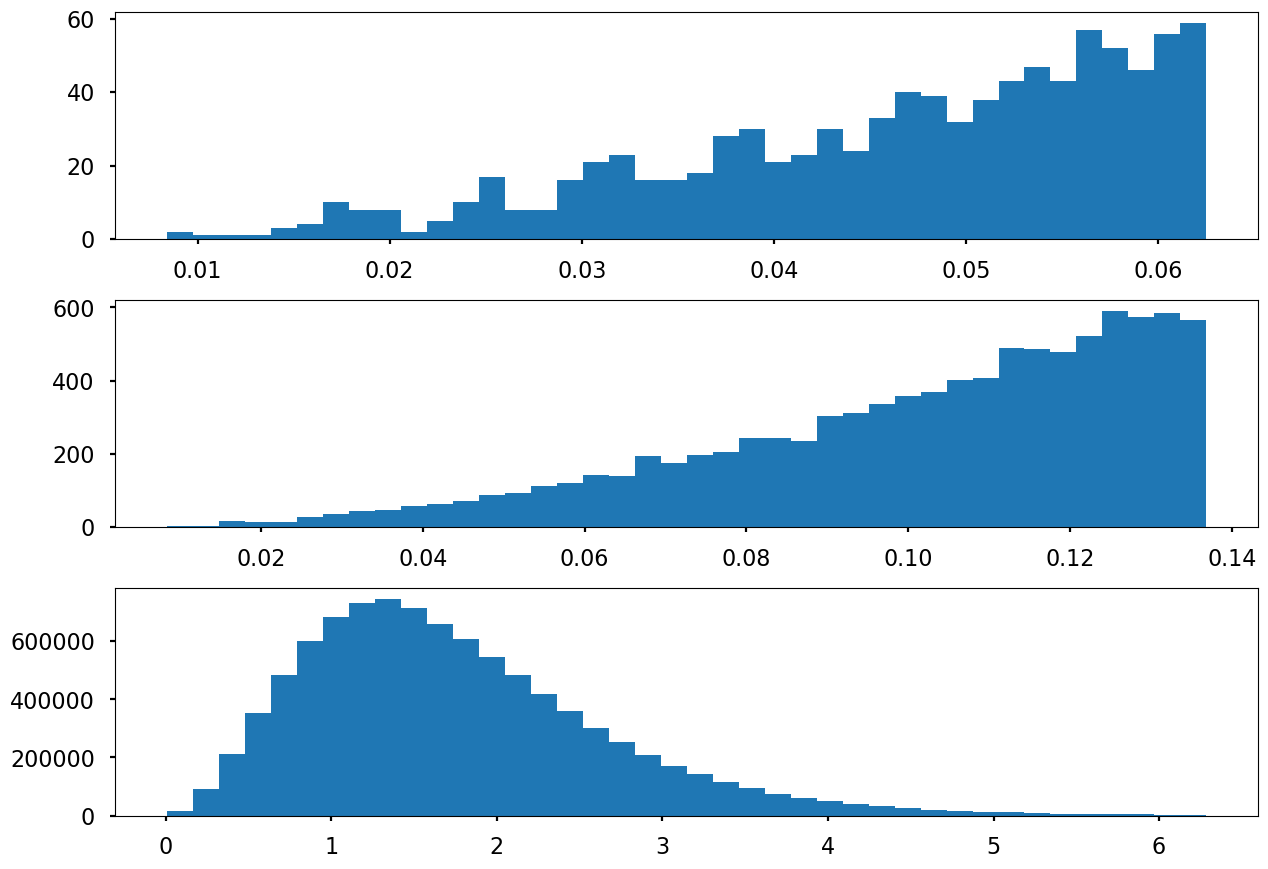

In [73]:
fig, ax = plt.subplots(3, 1, sharey=False, tight_layout=True)

ax[0].hist(tmp[tmp < np.quantile(tmp, 0.0001)], bins=40)
ax[1].hist(tmp[tmp < np.quantile(tmp, 0.001)], bins=40)
ax[2].hist(tmp[tmp < np.quantile(tmp, 0.999)], bins=40)

plt.show()

In [11]:
# PASTIS transfer function ONLY

alpha = -4

sc_counts = sc_dis_intramol.pow(alpha)
sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell distances:\n" + pd.Series(sc_dis_intramol.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nSingle-cell counts:\n" + sc_counts_series.describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

Single-cell distances:
count   9.4e+06
mean        1.8
std        0.93
min      0.0084
25%         1.1
50%         1.6
75%         2.2
max          11

Single-cell counts:
count   9.4e+06
mean    1.5e+02
std     9.1e+04
min       6e-05
25%       0.039
50%        0.16
75%        0.72
max       2e+08

Consensus counts:
count   4.5e+04
mean    1.4e+02
std     5.3e+03
min       0.058
25%         1.7
50%         4.3
75%          13
max       7e+05


In [ ]:
# sns.histplot(data=pd.Series(counts.values.ravel()).to_frame(), x=r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
# sns.histplot(data=counts, x=r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
sns.histplot(data=counts.values)
plt.x_axis(r"Pseudo-counts, $\alpha = " + f"{alpha}" + "$")
plt.show()

In [9]:
# PASTIS transfer function + 0.75um cutoff
alpha = -4

sc_counts = sc_dis_intramol.pow(alpha)
sc_counts[sc_dis_intramol.notnull() & (sc_dis_intramol > 0.75)] = 0
# sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell counts:\n" + pd.Series(sc_counts.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

sc_counts_series = None
counts.isnull().sum(), (counts == 0).sum()

Single-cell counts:
count   9.4e+06
mean    1.5e+02
std     9.1e+04
min           0
25%           0
50%           0
75%           0
max       2e+08

Consensus counts:
count   4.5e+04
mean    1.4e+02
std     5.3e+03
min           0
25%         1.4
50%           4
75%          13
max       7e+05


In [12]:
# 0.75um cutoff only

sc_counts = pd.DataFrame(0, index=sc_dis_intramol.index, columns=sc_dis_intramol.columns)
sc_counts[sc_dis_intramol.notnull() & (sc_dis_intramol <= 0.75)] = 1
# sc_counts_series = pd.Series(sc_counts.values.ravel())

counts = sc_counts.mean(axis=1)

print("Single-cell counts:\n" + pd.Series(sc_counts.values.ravel()).describe().to_string(float_format=lambda x: f"{x:.2g}"))
print("\nConsensus counts:\n" + counts.describe().to_string(float_format=lambda x: f"{x:.2g}"))

sc_counts_series = None
counts.isnull().sum(), (counts == 0).sum()

Single-cell counts:
count   1.7e+08
mean     0.0061
std       0.078
min           0
25%           0
50%           0
75%           0
max           1

Consensus counts:
count   4.5e+04
mean     0.0061
std       0.005
min           0
25%      0.0027
50%      0.0049
75%      0.0078
max       0.052


(np.int64(0), np.int64(103))

### Dist decay - pseudo-counts

In [ ]:
# XXX shouldn't the distance decay be for ambiguated counts? not that it'll make a huge difference...

#### c ~ d^alpha

v = 0.785
1/v = 1.27
est alpha = B/v = -1.02


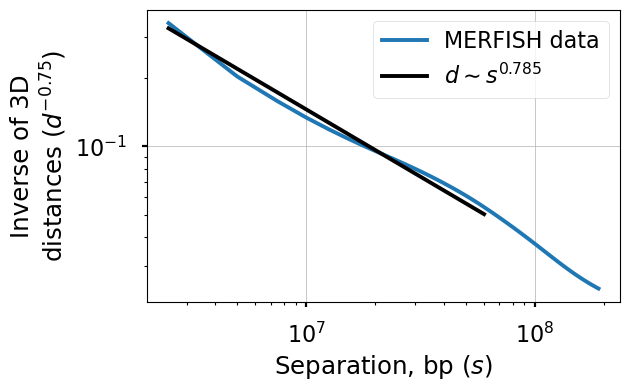

In [151]:
sigma_log10 = 0.1; min_n = None
# dis_exp = -4; min_distance = 0.1; max_distance = 0.75 # 0.162
# dis_exp = -4; min_distance = 0.1; max_distance = 1 # 0.161
# dis_exp = -4; min_distance = 0.1; max_distance = 0.5 # 0.164
# dis_exp = -4; min_distance = 0.01; max_distance = 0.5 # 0.151, noisy
# dis_exp = -4; min_distance = 0.05; max_distance = 0.5 # 0.167
# dis_exp = -4; min_distance = 0.025; max_distance = 0.5 # 0.177
# dis_exp = -3; min_distance = 0.025; max_distance = 0.5 # 0.223
# dis_exp = -3; min_distance = 0.025; max_distance = 0.2 # 0.231
# dis_exp = -2; min_distance = 0.025; max_distance = 0.5 # 0.312
# dis_exp = -2; min_distance = 0.025; max_distance = 0.2 # 0.339 ++
# dis_exp = -2; min_distance = 0.025; max_distance = 0.1 # 0.346, noisier than max_dist=0.2
# dis_exp = -2; min_distance = 0.015; max_distance = 0.2 # 0.335
# dis_exp = -2; min_distance = 0.05; max_distance = 0.2 # 0.335
# dis_exp = -2; min_distance = 0.02; max_distance = 0.2 # 0.337

# dis_exp = -1; min_distance = 0.025; max_distance = 0.5 # 0.593
# dis_exp = -1; min_distance = 0.025; max_distance = 0.2 # 0.666 ++
# dis_exp = -0.75; min_distance = 0.025; max_distance = 0.2 # 0.886 ++
# dis_exp = -0.75; min_distance = 0.025; max_distance = None # 0.201 ++
dis_exp = -0.75; min_distance = None; max_distance = 0.2 # 0.886 ++
# dis_exp = -0.75; min_distance = None; max_distance = 0.5 # 0.785 ++
# dis_exp = -0.5; min_distance = 0.025; max_distance = 0.5 # 1.17
# dis_exp = -0.2; min_distance = 0.025; max_distance = 0.5 # 2.89
# dis_exp = -1; min_distance = None; max_distance = None  # 0.204 ++
# dis_exp = -0.2; min_distance = None; max_distance = None  # 0.196 ++
# dis_exp = -0.75; min_distance = None; max_distance = None  # 0.201 ++
# dis_exp = -1.5; min_distance = None; max_distance = None  # 0.209 ++
# dis_exp = -2; min_distance = None; max_distance = None  # 0.214 ++
# dis_exp = -2.5; min_distance = None; max_distance = None  # 0.214 ++
# dis_exp = -3; min_distance = None; max_distance = None  # 0.201 ++


counts_sc = sc_dis_intramol.pow(dis_exp)
if min_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol < min_distance)] = np.power(min_distance, dis_exp)
if max_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol > max_distance)] = 0
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_genomic_dist_by_cell(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

#### c = std logistic of x=-ln(d)

v = 0.661
1/v = 1.51
est alpha = B/v = -1.21


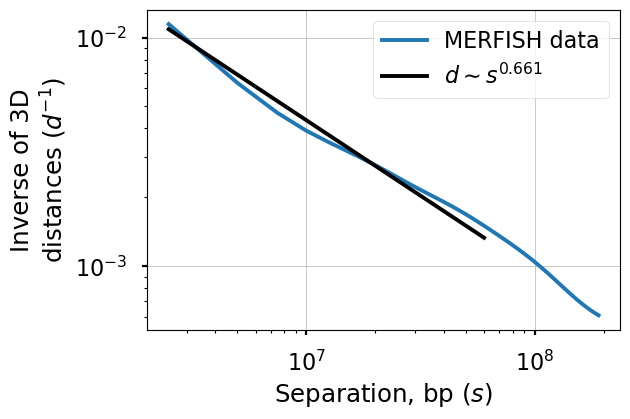

In [65]:
sigma_log10 = 0.1; min_n = None
# dis_exp = -4; min_distance = None; max_distance = None # 0.0853
# dis_exp = -4; min_distance = 0.01; max_distance = 0.75 # noise
# dis_exp = -3; min_distance = None; max_distance = None # 0.0913
# dis_exp = -2; min_distance = None; max_distance = None # 0.0974
# dis_exp = -1; min_distance = None; max_distance = None # 0.103
# dis_exp = -0.5; min_distance = None; max_distance = None # 0.106
# dis_exp = -0.25; min_distance = None; max_distance = None # 0.107

# dis_exp = -4; min_distance = None; max_distance = 0.75 # 0.131
# dis_exp = -4; min_distance = None; max_distance = 0.5 # 0.148
# dis_exp = -4; min_distance = None; max_distance = 0.2 # 0.166
# dis_exp = -3; min_distance = None; max_distance = 0.2 # 0.221
# dis_exp = -1; min_distance = None; max_distance = 0.75 # 0.494
# dis_exp = -1; min_distance = None; max_distance = 0.5 # 0.579
dis_exp = -1; min_distance = None; max_distance = 0.2 # 0.661

counts_sc = (1 + sc_dis_intramol).pow(dis_exp)  # power law where x=d+1 OR logistic fxn of x where x = -ln(d)
# alternative (1 + e^(10*(d-0.5)))^-1) = based on logistic fxn of x where x = -d (equiv to "1 - [logistic fxn of d]")
if min_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol < min_distance)] = np.power(min_distance, dis_exp)
if max_distance is not None:
    counts_sc[sc_dis_intramol.notnull() & (sc_dis_intramol > max_distance)] = 0
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_genomic_dist_by_cell(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

#### c = logistic of x=

v = 0.681
1/v = 1.47
est alpha = B/v = -1.18


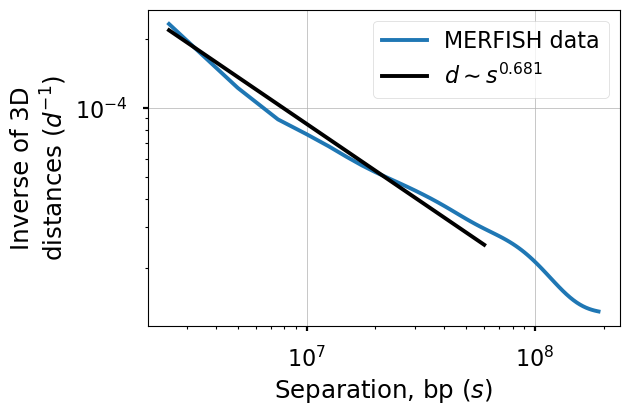

In [140]:
sigma_log10 = 0.1; min_n = None
L = 1
# k = -3;   x0=-0.5  # 0.412
# k = -10;   x0=-0.2  # 0.61
# k = -10;   x0=-0.1  # 0.608
# k = -15;   x0=-0.1  # 0.643
# k = -15;   x0=0     # 0.641
# k = -20;   x0=0     # 0.659
# k = -30;   x0=0     # 0.659
# k = -35;   x0=0     # 0.68
# k = -37;   x0=0     # 0.69
# k = -38;   x0=0     # 0.683
k = -39;   x0=+0.01     # 0.681
# k = -10;   x0=-0.5  # ??



def logistic(x, x0, k, L=1, v=1):
    # x0 <= 0 and k<0
    tmp = -k * (x - x0)
    # try1 = L / np.power(1 + np.exp(-k * (x - x0)), 1 / v)
    try2 = np.exp(np.log(L) - np.log1p(np.exp(tmp))) / v
    return try2



counts_sc = logistic(sc_dis_intramol, x0=x0, k=k, L=L)
counts = counts_sc.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
counts_sc = None
counts_by_s = get_genomic_dist_by_cell(counts, dis_exp=1, min_n=min_n)

counts_by_s_smooth = smooth_frequency(counts_by_s, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(counts_by_s_smooth, seed=0, dis_exp=dis_exp, verbose=True)

In [10]:
def logistic_fun(x, x0, k, L=1):
    # x0 <= 0 and k<0
    tmp = -k * (x - x0)
    # try1 = L / (1 + np.exp(-k * (x - x0)))
    try2 = np.exp(np.log(L) - np.log1p(np.exp(tmp)))
    return try2

counts_sc = logistic_fun(sc_dis_intramol, x0=0, k=-10, L=1)

counts_sc.index = [j - i for i, j in counts_sc.index]

counts_sc = None

In [ ]:
counts_sc.groupby(level=0).var().mean(axis=1)

In [135]:
x = 10

correct = L / (1 + np.exp(x))
testing = np.exp(np.log(L) - np.log1p(np.exp(x)))
print(f"{correct=:.10}\n{testing=:.10g}")


# correct = 1 + np.exp(x)
# testing = np.exp(np.log1p(np.exp(x)))
# print(f"{correct=:.10}\n{testing=:.10g}")

correct=4.53978687e-05
testing=4.53978687e-05


## Analyze

In [ ]:
min_n = None
# dis_exp = -1; sigma_log10 = 0.01  # 1/exp = 4.9;   1/exp * dis_exp = 4.9;
# dis_exp = -3; sigma_log10 = 0.2   # 1/exp = ~2;    1/exp * dis_exp = 6;
# dis_exp = -0.5; sigma_log10 = 0.1   # 1/exp = 10;  1/exp * dis_exp = 5;
# dis_exp = -5; sigma_log10 = 0.1   # 1/exp =  2;    1/exp * dis_exp =  10;
# dis_exp = 1; sigma_log10 = 0.1  # 1/exp = 5.38;                        
dis_exp = -1; sigma_log10 = 0.1  # 1/exp = 4.9;   1/exp * dis_exp = 4.9
# dis_exp = -1; sigma_log10 = 0.1; min_n = 5; # similar to without min_n

s_by_cell = get_genomic_dist_by_cell(sc_dis_intramol, dis_exp=dis_exp, min_n=min_n)
s_by_cell_smooth = smooth_frequency(s_by_cell, sigma_log10=sigma_log10)
display(s_by_cell_smooth.head(3))
display(s_by_cell_smooth.tail(3))
# s_by_cell_smooth.n[s_by_cell_smooth.n != 0].describe()



======= MEAN =======

v = 0.195
1/v = 5.14
est alpha = B/v = -4.11


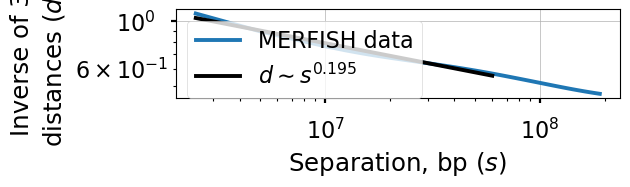



======= MEDIAN =======

v = 0.195
1/v = 5.14
est alpha = B/v = -4.11


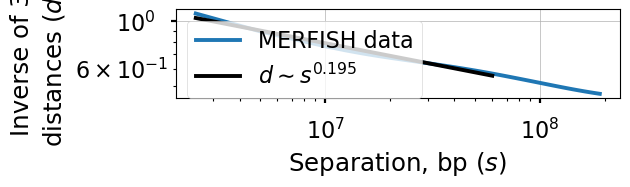

In [25]:
min_n = None
dis_exp = -1; sigma_log10 = 0.1

for agg in ('mean', 'median'):
    print(f"\n\n======= {agg.upper()} =======\n")
    sc_dis_intramol_mean = sc_dis_intramol.median(axis=1).to_frame().rename({0: f'sc_{agg}'}, axis=1)
    s_agg = get_genomic_dist_by_cell(sc_dis_intramol_mean, dis_exp=dis_exp, min_n=min_n)
    s_agg_smooth = smooth_frequency(s_agg, sigma_log10=sigma_log10)
    d, (x, y), est_alpha = estimate_exponent_manual(s_agg_smooth, seed=0, dis_exp=dis_exp, verbose=True)

v = -1.23
1/v = -0.816
est alpha = B/v = 0.653


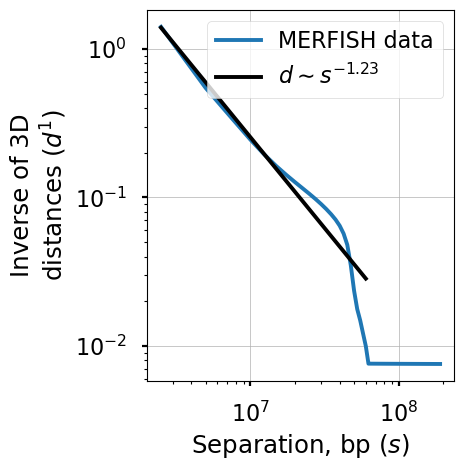

In [28]:
min_n = None
dis_exp = 1; sigma_log10 = 0.1

agg = 'median'  # for agg in ('mean', 'median'):
# print(f"\n\n======= {agg.upper()} =======\n")
sc_dis_intramol_mean = sc_dis_intramol.median(axis=1).to_frame().rename({0: f'sc_{agg}'}, axis=1)
s_agg = get_genomic_dist_by_cell(sc_dis_intramol_mean, dis_exp=dis_exp, min_n=min_n) ** -5
s_agg_smooth = smooth_frequency(s_agg, sigma_log10=sigma_log10)
d, (x, y), est_alpha = estimate_exponent_manual(s_agg_smooth, seed=0, dis_exp=dis_exp, verbose=True)

### Get exponent per cell

In [336]:
def get_exponent_per_cell(df, dis_exp):
    genomic_dis = df.index.values
    freq_smooth = df.smoothed_freq.values.ravel()
    
    d = estimate_exponent(genomic_dis, freq_smooth=freq_smooth, verbose=False)
    # d = estimate_exponent(
    #     genomic_dis, freq_smooth=freq_smooth, x0=x0, bounds=bounds, seed=seed,
    #     max_iter=max_iter, verbose=False)

    v = d['exponent'] / dis_exp
    detected_genomic_dis = s = df[df.n > 0].index.values
    res = {
        'v': v, 'n_sum': df.n.sum(), 'detected_sum': df.n.notnull().sum(),
        's_size': int(s.size), 's_mean': s.mean(), 's_median': np.median(s),
        's_range': int(s.max() - s.min() + 1)}
    return pd.Series(res)


min_genomic_dis = None; max_genomic_dis = 'default'

if min_genomic_dis is None:
    min_genomic_dis = s_by_cell_smooth.index.min()
if max_genomic_dis is None:
    max_genomic_dis = s_by_cell_smooth.index.max()
elif isinstance(max_genomic_dis, str) and max_genomic_dis.lower() == 'default':
    max_genomic_dis = 6e7
mask = (s_by_cell_smooth.index <= max_genomic_dis) & (s_by_cell_smooth.index >= min_genomic_dis)

# tmp = s_by_cell_smooth[mask].groupby('cell_num').apply(get_exponent_per_cell, dis_exp=dis_exp, include_groups=False)
# n_sum = s_by_cell_smooth[mask].groupby('cell_num').n.sum().to_frame().rename({'n': 'n_sum'}, axis=1)
# per_cell = pd.concat([n_sum, tmp.to_frame().rename({0: 'v'}, axis=1)], axis=1)

per_cell = s_by_cell_smooth[mask].groupby('cell_num').apply(get_exponent_per_cell, dis_exp=dis_exp, include_groups=False)
for col in [col in per_cell.columns if col != 'v']:  #['n_sum', 's_size', 's_mean', 's_median', 's_range']:
    per_cell[col] = per_cell[col].astype(int)

In [372]:
min_nsum = int(round(per_cell.n_sum.quantile(0.5)))

display(per_cell.describe().round(2))
print('\ns < -0.25')
display(per_cell[per_cell.v < -0.25].describe().round(2))
print(f'\nn_sum > {min_nsum}')
display(per_cell[per_cell.n_sum >= min_nsum].describe().round(2))

pairs_per_cell = s_by_cell_smooth[mask].groupby('cell_num').n.sum()
cells_to_use = pairs_per_cell[pairs_per_cell >= min_nsum].index
num_pairs_orig = sc_dis_intramol.notnull().values.sum()
num_pairs_final = sc_dis_intramol[cells_to_use].notnull().values.sum()
print(f"Retaining {round(num_pairs_final / num_pairs_orig * 100):g}% of pairs")

,v,n_sum,s_size,s_mean,s_median,s_range
count,3702.00,3702.00,3702.00,3702.00,3702.00,3702.00
mean,0.15,2536.00,59.65,30.07,30.07,60.44
std,0.34,2584.42,12.52,6.25,6.25,12.44
min,-2.74,28.00,15.00,9.00,9.00,17.00
25%,0.15,630.00,50.00,25.00,25.00,50.00
50%,0.19,1550.00,60.00,30.00,30.00,61.00
75%,0.23,3629.00,71.00,36.00,36.00,71.00
max,0.66,14663.00,76.00,38.00,38.00,76.00



s < -0.25


,v,n_sum,s_size,s_mean,s_median,s_range
count,53.00,53.00,53.00,53.00,53.00,53.00
mean,-2.44,106.66,23.25,12.08,12.19,24.25
std,0.77,108.89,7.71,3.83,3.85,7.69
min,-2.74,28.00,15.00,9.00,9.00,17.00
25%,-2.74,55.00,20.00,10.00,10.00,21.00
50%,-2.74,78.00,21.00,11.00,11.00,22.00
75%,-2.74,105.00,23.00,12.00,12.00,23.00
max,-0.26,631.00,55.00,28.00,28.00,57.00



n_sum > 1550


,v,n_sum,s_size,s_mean,s_median,s_range
count,1852.00,1852.00,1852.00,1852.00,1852.00,1852.00
mean,0.20,4375.34,67.95,34.22,34.22,68.58
std,0.05,2533.50,7.05,3.52,3.52,7.09
min,-0.08,1550.00,47.00,24.00,24.00,47.00
25%,0.17,2355.00,61.00,31.00,31.00,61.00
50%,0.20,3629.00,70.00,35.00,35.00,71.00
75%,0.23,5704.25,75.00,38.00,38.00,75.00
max,0.40,14663.00,76.00,38.00,38.00,76.00


Retaining 86% of pairs


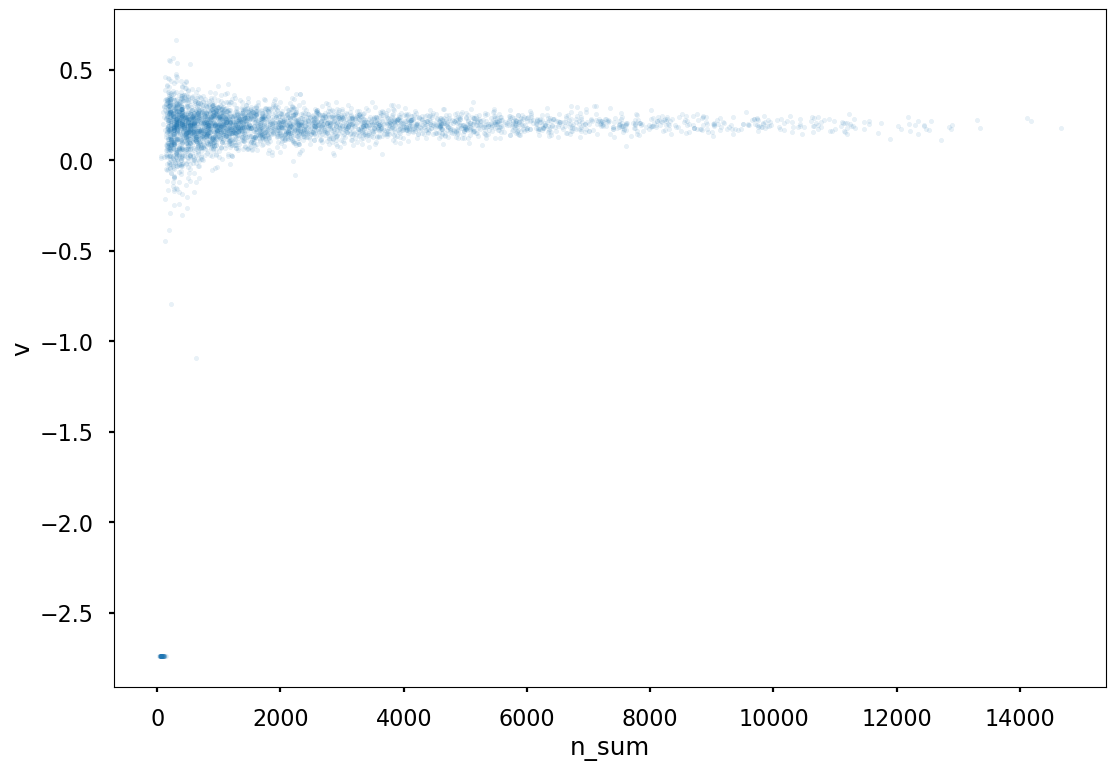

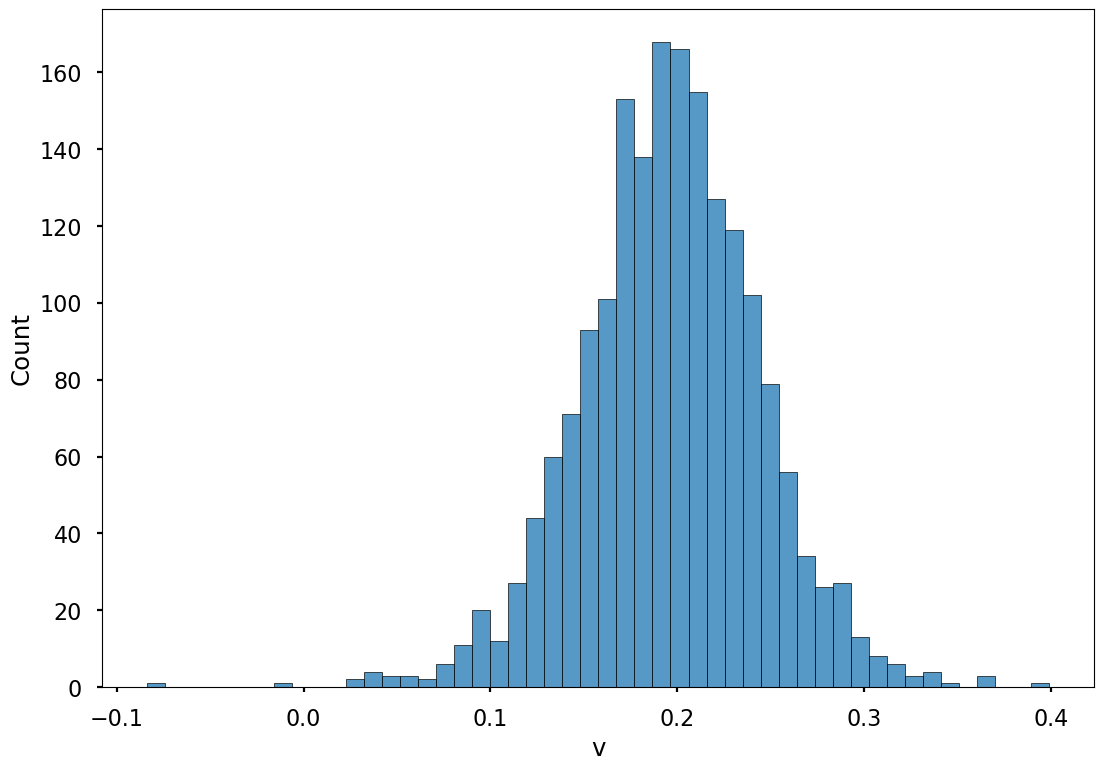

In [367]:
sns.scatterplot(data=per_cell, x="n_sum", y="v", s=10, alpha=0.1, edgecolors=None)  # 
plt.show()

sns.histplot(data=per_cell[per_cell.n_sum > per_cell.n_sum.quantile(0.5)], x="v")
plt.show()

## Plot

v = 0.143
1/v = 7.02
est alpha = B/v = -5.61


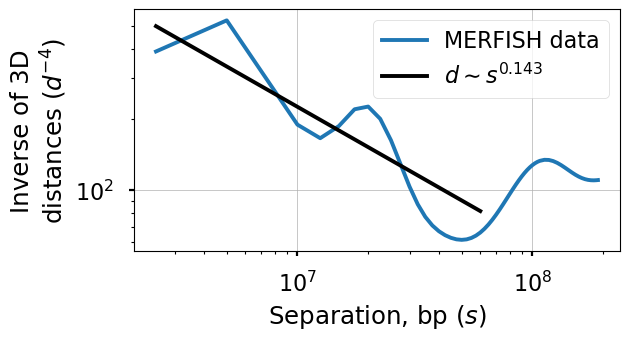

v = 0.143
1/v = 7.02
est alpha = B/v = -5.61


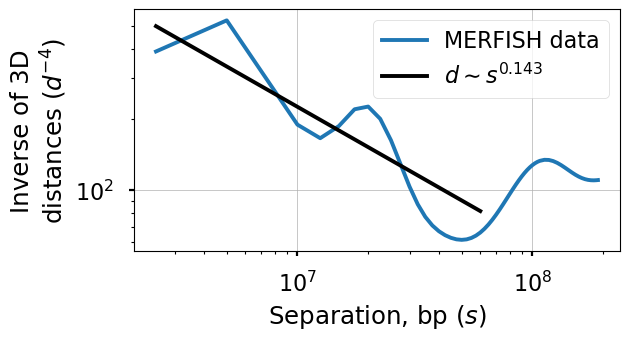

In [93]:
min_nsum = 0


data_smooth = s_smooth
data_orig = s_by_cell
if min_nsum > 1:
    pairs_per_cell = s_smooth[s_smooth.n >= min_nsum].groupby('cell_num').n.sum()
    cells_to_use = pairs_per_cell[pairs_per_cell >= min_nsum].index
    num_pairs_orig = sc_dis_intramol.notnull().values.sum()
    num_pairs_final = sc_dis_intramol[cells_to_use].notnull().values.sum()
    print(f"Retaining {round(num_pairs_final / num_pairs_orig * 100):g}% of pairs\n\n")
    data_smooth = data_smooth[data_smooth.cell_num.isin(cells_to_use)]
    data_orig = data_orig[cells_to_use]
# data_smooth = data_smooth.copy(); data_smooth[data_smooth.n < 40] = np.nan

# s_smooth_mean = data_smooth.groupby(level=0).mean().drop('cell_num', axis=1)
# # display(s_smooth_mean.head(2)); display(s_smooth_mean.tail(2))
# d, (x, y), est_alpha = estimate_exponent_manual(s_smooth_mean, seed=0, dis_exp=dis_exp, verbose=True)

# s_smooth_med = data_smooth.groupby(level=0).median().drop('cell_num', axis=1)
# # display(s_smooth_med.head(2)); display(s_smooth_med.tail(2))
# d, (x, y), est_alpha = estimate_exponent_manual(s_smooth_med, seed=0, dis_exp=dis_exp, verbose=True)

s_by_cell_mean = data_orig.mean(axis=1).to_frame().rename({0: 'sc_mean'}, axis=1)
s_mean_smooth = smooth_frequency(s_by_cell_mean, sigma_log10=0.1)
# display(s_mean_smooth.head(2)); display(s_mean_smooth.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(s_mean_smooth, seed=0, dis_exp=dis_exp, verbose=True)


s_by_cell_med = data_orig.median(axis=1).to_frame().rename({0: 'sc_median'}, axis=1)
s_med_smooth = smooth_frequency(s_by_cell_mean, sigma_log10=0.1)
# display(s_med_smooth.head(2)); display(s_med_smooth.tail(2))
d, (x, y), est_alpha = estimate_exponent_manual(s_med_smooth, seed=0, dis_exp=dis_exp, verbose=True)

## Fxn

In [ ]:
%run fit_dist_decay.py

In [2]:
n = 11
x_true = np.triu(np.ones((n, n)), 1).sum()
x = (n ** 2 - n) / 2
n_result = int((1 + np.sqrt(1 + 8 * x)) / 2)
print(x_true, x)
print(n, n_result)

55.0 55.0
11 11
